In [1]:
from utils.consts import * ## const variables are there, so paths and extraction features ##
from utils. plotting import * ## plotting ##
from data_reader_babalit import * ## the class which reads balabit dataset ##
from data_reader_chaoshen import * ## the class which reads chaoshen datasets TODO There are several issues with this dataset -> explained later ##
from legality_analyser import * ## the class which analyses the datasets with 0 1 labels --> splitting samples is being done there ##  
import random


In [2]:
users = [7,9,15,16,20,21,23,29, 35]
balabit_reader = DataReaderBalabit(BALABIT, users, True, limit = 1000) ## the arguments are DATASET, users, supervised, how many records should be procesed ##



In [2]:
from RFmodel import *
from nonlegality_analyser import * ## the class which analyses the datasets without 0 1 labels --> splitting samples is being done there ##  


User 7 is being analyzed:
CV Accuracy: 0.94 (+/- 0.02)
Test Accuracy: 0.83
7: 1.000 threshold: 0.435
User 9 is being analyzed:
CV Accuracy: 0.96 (+/- 0.02)
Test Accuracy: 0.90
9: 1.000 threshold: 0.488
User 15 is being analyzed:
CV Accuracy: 0.70 (+/- 0.06)
Test Accuracy: 0.70
15: 0.949 threshold: 0.507
User 16 is being analyzed:
CV Accuracy: 0.69 (+/- 0.05)
Test Accuracy: 0.62
16: 0.908 threshold: 0.475
User 20 is being analyzed:
CV Accuracy: 0.83 (+/- 0.03)
Test Accuracy: 0.80
20: 0.984 threshold: 0.467
User 21 is being analyzed:
CV Accuracy: 0.72 (+/- 0.05)
Test Accuracy: 0.71
21: 0.951 threshold: 0.522
User 23 is being analyzed:
CV Accuracy: 0.71 (+/- 0.06)
Test Accuracy: 0.69
23: 0.954 threshold: 0.502
User 29 is being analyzed:
CV Accuracy: 0.78 (+/- 0.07)
Test Accuracy: 0.75
29: 0.984 threshold: 0.507
User 35 is being analyzed:
CV Accuracy: 0.69 (+/- 0.05)
Test Accuracy: 0.62
35: 0.923 threshold: 0.453


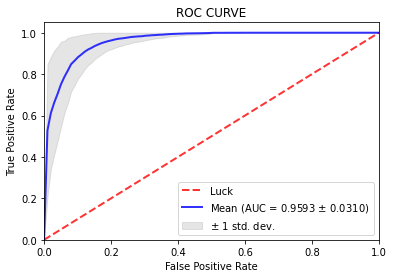

In [4]:
shuffle = True
## dictionaries of fpr tpr ## 
fpr = {}
tpr = {}
roc_auc = {}

# ONE USER IS ALWAYS LEGAL ##
for legalUser in users:
    ## this function gets all samples of legaluser and then randomly selects the samples from other users - The data will be balanced ## 
    balabit_reader.processDataWithLabels(legalUser, training = True, test = True  )
    path = balabit_reader.getFile()
    legality_analyser = legalityAnalyser(path)
    dataset = legality_analyser.createTrainingData(balanced = True)

    ## the last label is 0 and 1
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
   
    X_train, X_validation, y_train, y_validation = legality_analyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    model = RFModel(dataset, users)
    ## evaluating the model, the variables are X_train, y_train, X_validation, y_validation, scale --> use standardScler, and legalUser
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(f"{legalUser}: {roc_auc[legalUser]:.3f} threshold: {threshold:.3f}")

plotROCs(fpr, tpr, roc_auc, users)

In [5]:
print(type(dataset))

<class 'numpy.ndarray'>


In [6]:
dataframe = pd.DataFrame(dataset)


In [7]:
dataframe

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,3.0,469.505224,0.843,7.0,0.917768,45.0,-24.585210,-0.034119,0.392581,1.570796,...,34088.798703,145429.942387,-57812.775951,3.540406e+05,3.558374e+06,1.524072e+07,-8.381305e+06,0.063,7.0,1.0
1,1.0,579.414415,1.684,3.0,0.836328,67.0,22.468556,0.084355,1.003846,5.961435,...,55999.473506,366491.143511,-162780.995804,1.170136e+05,8.549318e+06,3.866977e+07,-5.292721e+07,0.062,7.0,1.0
2,3.0,619.458218,1.154,0.0,0.731371,62.0,-19.992962,-0.018320,0.233954,1.570796,...,38819.800574,187725.023490,-101976.848702,1.532948e+04,3.970159e+06,1.047904e+07,-1.931346e+07,0.062,7.0,1.0
3,1.0,647.331411,1.591,6.0,0.559296,79.0,-24.302650,-0.001366,1.074935,5.497787,...,31399.774305,157488.287765,-166584.312206,3.044227e+04,3.232120e+06,1.062743e+07,-2.025454e+07,0.046,7.0,1.0
4,1.0,326.058022,0.858,2.0,0.960030,50.0,104.674909,0.008429,0.212336,0.785398,...,15661.629934,40686.599680,-50270.692407,7.012474e+04,1.468407e+06,2.892458e+06,-4.706735e+06,0.124,7.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4683,1.0,1312.983684,1.731,3.0,0.921812,18.0,22.011347,0.196939,0.591399,2.418372,...,31908.814624,110784.388153,-26072.378310,9.718238e+05,3.198931e+06,1.107610e+07,-1.321190e+06,0.218,0.0,NaN
4684,1.0,2542.648781,1.373,2.0,0.203524,13.0,-6.047543,-0.008673,0.055229,0.074247,...,17596.004187,34623.309014,-19659.292014,1.759937e+04,2.622202e+05,4.934782e+05,-4.942721e+05,0.109,0.0,NaN
4685,1.0,405.394807,0.703,7.0,0.596000,70.0,-64.948722,-0.000909,0.341311,1.570796,...,23619.165937,74871.372522,-43307.274635,3.728383e+05,3.231705e+06,7.049893e+06,-6.316502e+06,0.010,0.0,NaN
4686,3.0,465.948376,1.123,3.0,0.861295,14.0,13.650166,-0.012303,0.060114,0.067274,...,136998.193411,394434.538046,-41302.771025,6.733943e+06,1.359364e+07,3.876314e+07,-3.997590e+06,0.010,0.0,NaN


In [16]:
dataframe[40].value_counts()

1.0    1847
0.0    1847
Name: 40, dtype: int64

In [19]:
xtraiin = pd.DataFrame(X_train)
xtraiin


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,3.0,36.088198,2.122,5.0,0.982041,7.0,-9.289449,-0.053067,0.090529,0.049073,...,36.806053,343.856832,570.425504,-292.663813,-1.201827e+02,4.787134e+03,5.313111e+03,-6.560042e+03,0.140,35.0
1,1.0,200.092974,0.499,0.0,0.880102,7.0,-1.891536,-0.013280,0.018741,0.011780,...,25817.447095,41910.171943,104244.091048,-8168.184236,2.636262e+06,4.406534e+06,1.064745e+07,-4.653641e+05,0.093,21.0
2,3.0,370.810553,1.201,1.0,0.975450,10.0,7.438962,-0.008735,0.024344,0.015730,...,59.588928,3428.638695,5576.934759,-4695.665375,-9.014942e+02,4.100168e+04,4.712850e+04,-9.424404e+04,0.219,35.0
3,1.0,89.738434,0.390,0.0,0.992335,5.0,2.755797,0.296313,0.565403,1.180189,...,32476.199562,68404.679151,138416.842327,-11860.901796,3.116947e+06,6.708041e+06,1.350680e+07,-1.065800e+06,0.135,35.0
4,1.0,431.570909,1.357,3.0,0.821453,13.0,14.255993,0.022088,0.188948,0.469064,...,-51.936729,2512.771169,4375.990767,-5059.291519,-2.213234e+03,2.898526e+04,2.982373e+04,-5.997548e+04,0.125,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2581,1.0,516.194887,1.545,0.0,0.971296,11.0,2.489131,-0.009824,0.017680,0.007553,...,638.253853,5534.860053,10941.839892,-10615.098549,6.449834e+03,6.413209e+04,1.242705e+05,-1.007072e+05,0.219,15.0
2582,1.0,71.519563,0.437,5.0,0.993031,7.0,-10.225882,-0.032532,0.051928,0.042092,...,24930.621993,53852.085513,133416.640641,-9545.367992,2.627351e+06,5.434055e+06,1.334166e+07,-1.311578e+06,0.010,29.0
2583,3.0,186.804239,1.061,5.0,0.754497,90.0,-135.442261,-0.009602,0.850205,4.712389,...,1232.221233,9244.703852,37514.738080,-23913.645134,1.441083e+05,1.182022e+06,5.219192e+06,-3.426352e+06,0.015,9.0
2584,3.0,217.242756,0.827,0.0,0.755884,9.0,0.865925,0.134280,0.586910,1.352127,...,-162.110353,3890.687016,8083.278543,-5654.507782,-1.594451e+03,5.532872e+04,6.466623e+04,-1.260347e+05,0.125,35.0


In [20]:
yasd = pd.DataFrame(y_train)
yasd


,0
0,1.0
1,0.0
2,1.0
3,1.0
4,1.0
...,...
2581,0.0
2582,0.0
2583,0.0
2584,1.0


In [26]:
balabit_reader.processDataWithLabels(9, training = True, test = True  )
path = balabit_reader.getFile()
legality_analyser = legalityAnalyser(path)
dataset = legality_analyser.createTrainingData(balanced = True)



In [31]:
pandadataset = pd.DataFrame(dataset)
pandadataset

,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,40
0,3.0,406.450941,1.389,5.0,0.812595,146.0,-246.521977,0.027835,0.755936,5.695183,...,14418.554724,76592.765857,-45761.740895,2.379535e+05,2.001805e+06,1.049805e+07,-7.051896e+06,0.010,9.0,1.0
1,1.0,60.306717,0.125,1.0,0.855857,16.0,20.041052,0.083469,0.350200,1.110721,...,16853.574353,31819.804557,-28020.804523,1.950450e+05,2.119846e+06,4.456982e+06,-3.740038e+06,0.025,9.0,1.0
2,3.0,71.032188,0.468,4.0,0.939445,39.0,-67.506286,0.105746,1.825540,5.497787,...,7912.959351,31622.776602,-11029.594830,1.621890e+05,1.099831e+06,3.162278e+06,-2.439648e+06,0.010,9.0,1.0
3,1.0,22.495751,0.203,1.0,0.961662,14.0,13.227414,0.079769,0.368599,0.785398,...,6199.187033,14084.184969,-6939.715261,6.726285e+04,7.332118e+05,1.245911e+06,-8.334609e+05,0.026,9.0,1.0
4,1.0,272.426179,0.047,6.0,0.997045,8.0,-5.586169,-0.001530,0.003041,0.002251,...,256522.669125,586003.412959,-194643.674858,5.112306e+06,3.505456e+07,5.860034e+07,-4.879044e+07,0.010,9.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.0,606.975575,1.419,1.0,0.727815,10.0,-2.380125,0.007186,0.087893,0.192875,...,12629.145165,32123.739979,-11157.745656,2.083546e+04,1.353112e+05,2.947132e+05,-1.687620e+05,0.109,9.0,0.0
4630,1.0,67.448366,0.452,7.0,0.955453,44.0,-33.215018,-0.035552,0.433603,1.570796,...,6108.576847,19891.711400,-18346.191347,1.028619e+05,8.861693e+05,2.579975e+06,-2.549194e+06,0.041,15.0,0.0
4631,3.0,1277.790984,3.307,1.0,0.261351,31.0,-4.134173,-0.013448,0.127671,0.310183,...,24596.483390,131228.831101,-16072.665485,3.975437e+05,2.453748e+06,1.330102e+07,-1.567037e+06,0.094,35.0,0.0
4632,4.0,33.242641,1.107,7.0,0.902957,25.0,-2.356194,-0.055532,0.574566,1.570796,...,3580.624788,6194.478272,-8593.750029,8.920994e+03,3.898360e+05,8.877315e+05,-9.500023e+05,0.093,7.0,0.0


In [28]:
X = dataset[:, 0:-1]
y = dataset[:, -1]

In [32]:
pandaX = pd.DataFrame(X)
pandaX

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,3.0,406.450941,1.389,5.0,0.812595,146.0,-246.521977,0.027835,0.755936,5.695183,...,1701.700284,14418.554724,76592.765857,-45761.740895,2.379535e+05,2.001805e+06,1.049805e+07,-7.051896e+06,0.010,9.0
1,1.0,60.306717,0.125,1.0,0.855857,16.0,20.041052,0.083469,0.350200,1.110721,...,2277.158208,16853.574353,31819.804557,-28020.804523,1.950450e+05,2.119846e+06,4.456982e+06,-3.740038e+06,0.025,9.0
2,3.0,71.032188,0.468,4.0,0.939445,39.0,-67.506286,0.105746,1.825540,5.497787,...,1304.810206,7912.959351,31622.776602,-11029.594830,1.621890e+05,1.099831e+06,3.162278e+06,-2.439648e+06,0.010,9.0
3,1.0,22.495751,0.203,1.0,0.961662,14.0,13.227414,0.079769,0.368599,0.785398,...,954.487114,6199.187033,14084.184969,-6939.715261,6.726285e+04,7.332118e+05,1.245911e+06,-8.334609e+05,0.026,9.0
4,1.0,272.426179,0.047,6.0,0.997045,8.0,-5.586169,-0.001530,0.003041,0.002251,...,60033.611730,256522.669125,586003.412959,-194643.674858,5.112306e+06,3.505456e+07,5.860034e+07,-4.879044e+07,0.010,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4629,1.0,606.975575,1.419,1.0,0.727815,10.0,-2.380125,0.007186,0.087893,0.192875,...,2373.606216,12629.145165,32123.739979,-11157.745656,2.083546e+04,1.353112e+05,2.947132e+05,-1.687620e+05,0.109,9.0
4630,1.0,67.448366,0.452,7.0,0.955453,44.0,-33.215018,-0.035552,0.433603,1.570796,...,1008.228437,6108.576847,19891.711400,-18346.191347,1.028619e+05,8.861693e+05,2.579975e+06,-2.549194e+06,0.041,15.0
4631,3.0,1277.790984,3.307,1.0,0.261351,31.0,-4.134173,-0.013448,0.127671,0.310183,...,4270.944033,24596.483390,131228.831101,-16072.665485,3.975437e+05,2.453748e+06,1.330102e+07,-1.567037e+06,0.094,35.0
4632,4.0,33.242641,1.107,7.0,0.902957,25.0,-2.356194,-0.055532,0.574566,1.570796,...,408.977320,3580.624788,6194.478272,-8593.750029,8.920994e+03,3.898360e+05,8.877315e+05,-9.500023e+05,0.093,7.0


In [33]:
panday = pd.DataFrame(y)
panday

,0
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0
...,...
4629,0.0
4630,0.0
4631,0.0
4632,0.0


In [34]:
    X_train, X_validation, y_train, y_validation = legality_analyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)


In [36]:
pandaX_train = pd.DataFrame(X_train)
pandaX_train

,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
0,1.0,121.110748,0.453,7.0,0.966093,32.0,-19.911250,-0.002887,0.404594,0.785398,...,3364.974034,20820.742434,58862.111240,-44298.368052,448086.144379,3.029882e+06,6.997322e+06,-5.373467e+06,0.026,9.0
1,3.0,15.478709,0.656,1.0,0.842344,15.0,18.527805,-0.043789,0.628147,0.909831,...,1253.544740,2934.313224,9093.452845,-2343.750000,55704.308221,3.744827e+05,9.242123e+05,-6.136988e+05,0.042,9.0
2,3.0,455.094155,1.217,4.0,0.836451,52.0,49.893227,0.000435,0.562126,3.059018,...,7648.592790,38144.598364,135191.503139,-91031.909959,448434.333173,3.395199e+06,1.115482e+07,-6.863512e+06,0.020,20.0
3,1.0,179.494751,2.964,4.0,0.428548,16.0,-3.787503,0.016299,0.354201,0.785398,...,46.086410,3052.424995,6708.698961,-5371.577066,-1693.901664,5.055597e+04,7.176455e+04,-1.155061e+05,0.124,21.0
4,1.0,341.724290,0.577,6.0,0.429384,67.0,-43.257876,0.026312,0.260238,1.570796,...,3062.770957,21639.786393,76592.765496,-66666.666667,417974.578848,3.048638e+06,8.666667e+06,-8.776519e+06,0.025,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3239,1.0,101.927658,0.421,5.0,0.934663,25.0,-38.678847,0.025433,2.040806,4.712389,...,3003.728471,14818.288184,53781.698597,-17887.493148,175256.459481,1.614380e+06,5.519374e+06,-3.350134e+06,0.015,7.0
3240,1.0,39.462851,0.765,5.0,0.126701,7.0,5.377862,-0.091968,1.559299,1.570796,...,235.360936,604.048426,1226.067301,-543.613959,1967.181067,7.189672e+03,1.427162e+04,-7.582157e+03,0.375,7.0
3241,1.0,55.390424,1.233,0.0,0.977569,10.0,-0.793559,-0.195648,0.587030,0.077469,...,83.953145,518.130824,929.080449,-505.007996,-9088.937233,3.235342e+04,1.315677e+04,-9.390430e+04,0.297,16.0
3242,4.0,94.643869,0.780,7.0,0.982688,49.0,-0.862170,0.003149,0.185206,0.785398,...,914.981044,7333.920623,21250.000000,-13333.333333,93011.274667,1.030443e+06,2.828125e+06,-2.305556e+06,0.088,9.0


In [37]:
panday_train = pd.DataFrame(y_train)
panday_train

,0
0,1.0
1,1.0
2,0.0
3,0.0
4,1.0
...,...
3239,0.0
3240,0.0
3241,0.0
3242,1.0


In [ ]:

## this function gets all samples of legaluser and then randomly selects the samples from other users - The data will be balanced ## 
## the last label is 1 or -1
X = dataset[:, 0:-1]
y = dataset[:, -1]
## train test split --> shuffle is used there ## if not used then data will be divided as x[0:halfTrainSamples] concatenate with X[positiveSamples: positiveSamples + trainHalfSamples]
## where positiveSamples is len(X/2)

X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
model = RFModel(dataset, users)
fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, scale = True, user = legalUser)




In [3]:
## Specyfing the USERS ## 
users = [7,9,15,16,20,21,23,29, 35]
## Creating the object which analyses the dataset ## 
balabit_reader = DataReaderBalabit(BALABIT, users, False, limit = 1100) ## the arguments are DATASET, users, supervised, how many records should be procesed ##
balabit_reader.processDataWithoutLabels() ## creating the data without labels ##


In [4]:
## getting path from the reader ## 
path = balabit_reader.getFile()
## creating analyser class ## 
balabitAnalyser = nonLegalityAnalyser(path)
## counting how many actions were extracted ## 
print(balabitAnalyser.countActions())

type_of_action     1    3    4
userid                        
7                772  897   98
9                872  904  117
15               585  707  101
16               588  666  125
20              1264  910  104
21               776  603  101
23               542  774   64
29               412  724  130
35               754  674  101


In [ ]:
from OneClassSVMModel import *

User 7 is being analyzed:
Test Accuracy: 0.57
7: 0.6827011224600281 threshold: -18.992482118385063
User 9 is being analyzed:
Test Accuracy: 0.55
9: 0.6826133871916594 threshold: -17.414113963523395
User 15 is being analyzed:
Test Accuracy: 0.54
15: 0.5748125674611277 threshold: -29.57984396260321
User 16 is being analyzed:
Test Accuracy: 0.52
16: 0.6313957846269163 threshold: -57.21063877894393
User 20 is being analyzed:
Test Accuracy: 0.51
20: 0.5462528003056457 threshold: -36.97394227081728
User 21 is being analyzed:
Test Accuracy: 0.58
21: 0.7207579273008506 threshold: -29.493907733421754
User 23 is being analyzed:
Test Accuracy: 0.60
23: 0.7727407724200196 threshold: -32.54826868486513
User 29 is being analyzed:
Test Accuracy: 0.51
29: 0.5099761140289325 threshold: -17.22775680841303
User 35 is being analyzed:
Test Accuracy: 0.58
35: 0.7316442356035116 threshold: -25.146891219861143


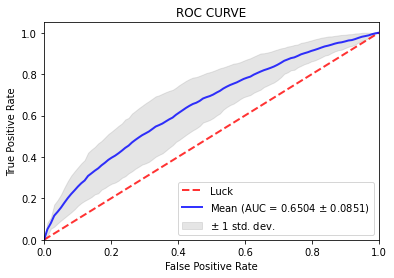

In [ ]:
fpr = {}
tpr = {}
roc_auc = {}
shuffle = True
for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    y_validation = np.where(y_validation == 0, -1, y_validation)

    model = OneClassSVMModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja 
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)

In [5]:
from IsolationForestModel import *

In [7]:
fpr = {}
tpr = {}
roc_auc = {}
shuffle = True
for legalUser in users:
    dataset = balabitAnalyser.createTrainingDataWithLabel(legalUser)
    X = dataset[:, 0:-1]
    y = dataset[:, -1]
    X_train, X_validation, y_train, y_validation = balabitAnalyser.trainingTestSplit(X, y, TEST_SIZE, shuffle)
    y_validation = np.where(y_validation == 0, -1, y_validation)

    model = IsolationForestModel(dataset, users)
    fpr[legalUser], tpr[legalUser], thr = model.evaluate(X_train, y_train, X_validation, y_validation, legalUser)
    threshold = -1
    try:
        eer = brentq(lambda x: 1. - x - interp1d(fpr[legalUser], tpr[legalUser])(x), 0., 1.) ## brentq znajdowanie 0 , interpid interpolacja 
        threshold = interp1d(fpr[legalUser], thr)(eer)

    except (ZeroDivisionError, ValueError):
        print("Division by zero")

    roc_auc[legalUser] = auc(fpr[legalUser], tpr[legalUser])
    print(str(legalUser) + ": " + str(roc_auc[legalUser])+" threshold: "+str(threshold))

plotROCs(fpr, tpr, roc_auc, users)

User 7 is being analyzed:
Test Accuracy: 0.47


TypeError: evaluate_sequence_of_samples() got multiple values for argument 'num_actions'